In [1]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


El problema siempre comienza con dos cuerpos que se atraen gravitacionalmente

In [2]:
# En unidades canónicas
G = 1

m1 = 1
r1_vec_0 = np.array([0, 0, 0])
v1_vec_0 = np.array([0, 0, 0])

m2 = 1
r2_vec_0 = np.array([1, 0, 0])
v2_vec_0 = np.array([0, 1, 0])

¿Cuál es la trayectoria que siguen las dos partículas con esas dos condiciones iniciales?


In [5]:
#Este es el problema que tiene solución analítica.
mu = G * (m1 + m2)
r_vec_0 = r1_vec_0 - r2_vec_0
r0 = np.linalg.norm(r_vec_0)

v_vec_0 = v1_vec_0 - v2_vec_0
v0 = np.linalg.norm(v_vec_0)

Calculemos las cuadraturas del problema


In [4]:
h_vec = np.cross(r_vec_0, v_vec_0)
h = np.linalg.norm(h_vec)

h_vec, h

(array([0, 0, 1]), np.float64(1.0))

In [6]:
e_vec = np.cross(v_vec_0, h_vec) / mu - r_vec_0 / r0
e = np.linalg.norm(e_vec)

e_vec, e

(array([0.5, 0. , 0. ]), np.float64(0.5))

In [8]:
epsilon = v0 ** 2 / 2 - mu / r0

epsilon

np.float64(-1.5)

Las partículas están ligadas por el signo de la energía y están sobre órbitas elípticas por el 0.5 de $e$ 

In [ ]:
# Verifiquemos la fórmula de e
e = np.sqrt(1 + 2*epsilon*h**2 / mu**2)
e

np.float64(0.5)

Cantidades geométricas derivadas

In [10]:
p = h**2 / mu
q = p / (1 + e)
Q = p / (1 - e)

p, q, Q

(np.float64(0.5), np.float64(0.3333333333333333), np.float64(1.0))

El máximo alejamiento es 1 (la posición inicial), el menor es 0.33 y el periatus rectum es 0.5

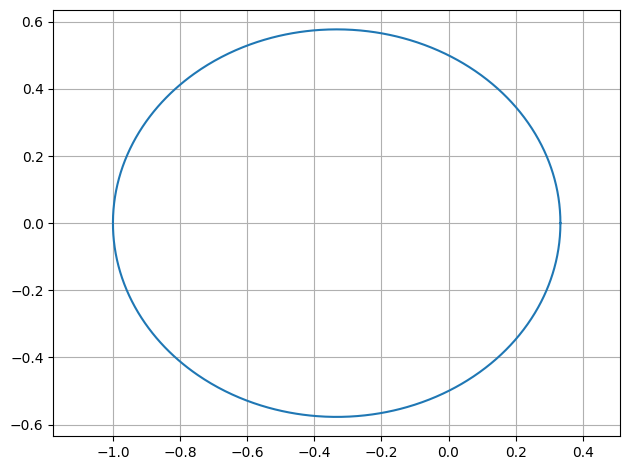

In [11]:
p = p
e = e
tetaers = np.linspace(0, 2 * np.pi, 1000)

rs = p / (1 + e * np.cos(tetaers))

xfs = rs * np.cos(tetaers)
yfs = rs * np.sin(tetaers)

plt.plot(xfs, yfs)
plt.axis('equal')
plt.grid()
plt.tight_layout()

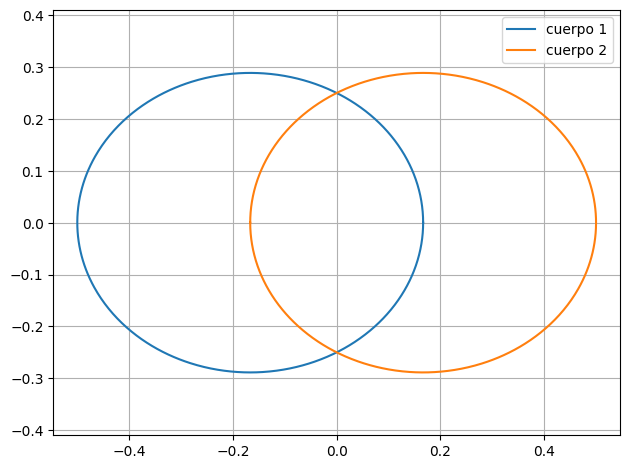

In [16]:
rvecs = np.array([xfs, yfs]).T
M = m1 + m2

r1vecs = m2/ M * rvecs
r2vecs = - m1/ M * rvecs

plt.plot(r1vecs[:,0], r1vecs[:,1], label='cuerpo 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='cuerpo 2')
plt.legend()
plt.axis('equal')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [17]:
sistema = [
    dict(r = r1_vec_0, v = v1_vec_0, m = m1),
    dict(r = r2_vec_0, v = v2_vec_0, m = m2)
]
ts = np.linspace(0, 10, 300)
rs, vs, rps, vps, cuadratura = pc.ncuerpos_solucion(sistema, ts)

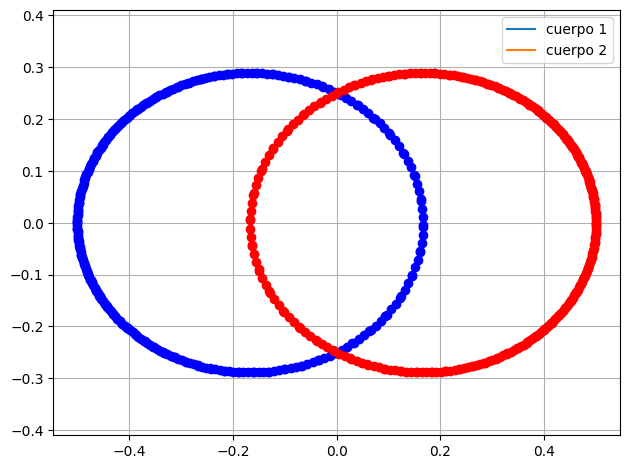

In [18]:
rvecs = np.array([xfs, yfs]).T
M = m1 + m2

r1vecs = m2/ M * rvecs
r2vecs = - m1/ M * rvecs

plt.plot(r1vecs[:,0], r1vecs[:,1], label='cuerpo 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='cuerpo 2')

plt.plot(rps[0, :, 0], rps[0, :, 1], 'bo')
plt.plot(rps[1, :, 0], rps[1, :, 1], 'ro')

plt.legend()
plt.axis('equal')
plt.grid()
plt.tight_layout()
plt.show()